# 1. Импорт библиотек

In [1]:
# Импорт основных библиотек
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Библиотеки для машинного обучения
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

## Вывод (пункт 1)

Подготовлено окружение и импортированы библиотеки: сначала стандартные модули Python, затем общие библиотеки для анализа данных и визуализации, после этого — библиотеки машинного обучения из sklearn, и в конце torch для нейросетевой части. sklearn используется для классических ML-моделей (например, Logistic Regression и Random Forest), а torch — для построения и обучения нейронной сети


# 2. Загрузка и разведовательный анализ данных

**Импортируем 2 файла:**

- train — данные, на которых модель учится находить закономерности.
- test — отдельные данные, которые модель не видела во время обучения; на них проверяют качество.

**Ссылка на данные:**

https://www.kaggle.com/competitions/tech-weekend-data-science-hackathon/data

**Выбранный датасет содержит 600 000 записей в обучающем наборе и 400 000 в тестовом. Каждая запись содержит id пациента и 13 признаков:**

- Age (возраст);
- Sex (пол);
- Resting_blood_pressure (артериальное давление в состоянии покоя);
- Serum_cholestoral (уровень холестерина в крови mg/dl);
- Fasting_blood_sugar (анализ глюкозы в крови натощак (> 120 mg/dl));
- Maximum_heart_rate_achieved (максимальная частота сердечных сокращений);
- Exercise_induced_angina (стенокардия при нагрузке),
- Oldpeak (депрессия ST-сегмента);
- Slope (наклон пикового сегмента ST при физической нагрузке);
- Number_of_major_vessels (количество крупных сосудов (0-3), окрашенных с помощью флюороскопии);
- Resting_electrocardiographic_results (результаты электрокардиографических исследований в покое 0, 1, 2);
- Thal (3 = норма; 6 = фиксированный дефект; 7 = обратимый дефект);
- Chest_bin (боль в груди от 1 до 4).

In [2]:
# Загрузка тренировочных данных
train = pd.read_csv('train.csv')

# Первые 5 строк обучающего набора данных
print("Обучающий набор данных:")
display(train.head())

Обучающий набор данных:


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


In [3]:
# Загрузка тествоых данных
test = pd.read_csv('test.csv')

# Первые 5 строк тестового набора данных
print("Набор тестовых данных:")
display(test.head())

Набор тестовых данных:


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
0,600000,53.963191,1,4.000000,136.940829,236.862814,0,2,143.961525,1,0.711100,1,2,7
1,600001,49.621479,1,4.000000,122.024651,226.593019,0,2,112.220874,1,0.000000,1,1,7
2,600002,36.933893,1,1.300924,127.585643,351.061046,0,0,177.945922,0,0.313078,1,0,7
3,600003,54.884588,1,3.000000,124.876745,250.370530,0,0,153.176526,0,0.308277,1,1,7
4,600004,71.016392,0,1.746972,120.922600,210.979710,0,0,164.573122,0,1.021370,1,1,3


In [4]:
print("Статистическое описание тестового набора данных:")
test.describe()

Статистическое описание тестового набора данных:


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
count,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.00000
mean,799999.500000,54.406917,0.676858,3.169252,131.369647,249.593475,0.151163,1.025295,149.659088,0.333085,1.050086,1.595072,0.681432,4.70715
std,115470.198175,9.101044,0.467677,0.950585,17.862279,51.720531,0.358208,0.994132,23.065911,0.471317,1.140986,0.628361,0.950323,1.93353
min,600000.000000,27.496874,0.000000,-0.337469,85.830892,94.958220,0.000000,0.000000,58.964662,0.000000,-0.601414,1.000000,0.000000,3.00000
25%,699999.750000,48.021226,0.000000,3.000000,119.942167,216.455450,0.000000,0.000000,135.818008,0.000000,0.000000,1.000000,0.000000,3.00000
50%,799999.500000,55.130138,1.000000,3.000000,129.735888,244.273212,0.000000,2.000000,153.337116,0.000000,0.816276,2.000000,0.000000,3.00000
75%,899999.250000,60.667833,1.000000,4.000000,139.935499,274.357993,0.000000,2.000000,165.216643,1.000000,1.671519,2.000000,1.000000,7.00000
max,999999.000000,80.751628,1.000000,4.000000,212.300808,527.712687,1.000000,2.000000,207.412021,1.000000,6.856219,3.000000,3.000000,7.00000


In [5]:
# Общая информация о тестовом датасете
print("Информация о тестовомнаборе данных:")
test.info()

Информация о тестовомнаборе данных:
<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    400000 non-null  int64  
 1   age                                   400000 non-null  float64
 2   sex                                   400000 non-null  int64  
 3   chest                                 400000 non-null  float64
 4   resting_blood_pressure                400000 non-null  float64
 5   serum_cholestoral                     400000 non-null  float64
 6   fasting_blood_sugar                   400000 non-null  int64  
 7   resting_electrocardiographic_results  400000 non-null  int64  
 8   maximum_heart_rate_achieved           400000 non-null  float64
 9   exercise_induced_angina               400000 non-null  int64  
 10  oldpeak                               40000

In [6]:
# Проверим пропущенные значения в тестовом наборе данных
print("Пропущенные значения в тестовом наборе данных:")
print(test.isnull().sum())

Пропущенные значения в тестовом наборе данных:
ID                                      0
age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
dtype: int64


In [7]:
print("Статистическое описание обучающего набора данных:")
train.describe()

Статистическое описание обучающего набора данных:


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,54.426085,0.677447,3.170247,131.340485,249.592420,0.150757,1.020148,149.592069,0.333502,1.051391,1.596033,0.681303,4.711378,0.444185
std,173205.225094,9.086041,0.467454,0.949618,17.842450,51.699976,0.357812,0.994204,23.072593,0.471464,1.144288,0.629821,0.950669,1.934766,0.496875
min,0.000000,26.061695,0.000000,-0.538498,82.918527,98.326263,0.000000,0.000000,61.844168,0.000000,-0.806788,1.000000,0.000000,3.000000,0.000000
25%,149999.750000,48.078493,0.000000,3.000000,119.924094,216.475964,0.000000,0.000000,135.704237,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,299999.500000,55.133425,1.000000,3.000000,129.727941,244.233699,0.000000,2.000000,153.224828,0.000000,0.811101,2.000000,0.000000,3.000000,0.000000
75%,449999.250000,60.663775,1.000000,4.000000,139.915216,274.345453,0.000000,2.000000,165.165497,1.000000,1.674081,2.000000,1.000000,7.000000,1.000000
max,599999.000000,79.591647,1.000000,4.000000,209.673650,527.755764,1.000000,2.000000,208.735196,1.000000,6.803372,3.000000,3.000000,7.000000,1.000000


In [8]:
# Общая информация об обучающем датасете
print("Информация об обучающем наборе данных:")
train.info()

Информация об обучающем наборе данных:
<class 'pandas.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               60

In [9]:
# Проверка пропущенных значений в обучающем наборе данных
print("Пропущенные значения в обучающем наборе данных:")
print(train.isnull().sum())

Пропущенные значения в обучающем наборе данных:
ID                                      0
age                                     0
sex                                     0
chest                                   0
resting_blood_pressure                  0
serum_cholestoral                       0
fasting_blood_sugar                     0
resting_electrocardiographic_results    0
maximum_heart_rate_achieved             0
exercise_induced_angina                 0
oldpeak                                 0
slope                                   0
number_of_major_vessels                 0
thal                                    0
class                                   0
dtype: int64


## Вывод (пункт 2)

На этапе загрузки и первичного анализа данных был изучен состав признаков, размер обучающей и тестовой выборок, а также структура целевой задачи. Предварительный обзор показал, что датасет содержит достаточный объем наблюдений для обучения и сравнения нескольких моделей. Пропусков данных в обучающей и тестовой выборке нет


# 3. Анализ данных

## 3.1 Базовые проверки: дубликаты, баланс классов, базовая валидация диапазонов

Дубликаты строк в train: 0
Дубликаты ID в train: 0

Распределение целевого класса (кол-во):
 class
0    333489
1    266511
Name: count, dtype: int64

Распределение целевого класса (доля):
 class
0    0.555815
1    0.444185
Name: proportion, dtype: float64


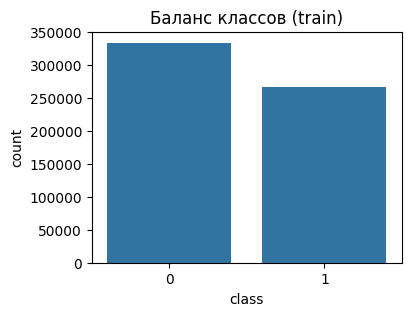


Количество значений вне ожидаемых диапазонов (train):
- sex: 0
- fasting_blood_sugar: 0
- resting_electrocardiographic_results: 0
- exercise_induced_angina: 0
- slope: 0
- number_of_major_vessels: 0
- thal: 0
- chest: 10392


In [10]:
# 3.1 Базовые проверки: дубликаты, баланс классов, базовая валидация диапазонов

# 1) Дубликаты
print("Дубликаты строк в train:", train.duplicated().sum())
print("Дубликаты ID в train:", train["ID"].duplicated().sum())

# 2) Баланс целевого класса
class_counts = train["class"].value_counts().sort_index()
class_share = train["class"].value_counts(normalize=True).sort_index()
print("\nРаспределение целевого класса (кол-во):\n", class_counts)
print("\nРаспределение целевого класса (доля):\n", class_share)

plt.figure(figsize=(4,3))
ax = sns.countplot(x="class", data=train)
ax.set_title("Баланс классов (train)")
ax.set_xlabel("class")
ax.set_ylabel("count")
plt.show()

# 3) Базовая проверка диапазонов категориальных признаков
range_checks = {
    "sex": (0, 1),
    "fasting_blood_sugar": (0, 1),
    "resting_electrocardiographic_results": (0, 2),
    "exercise_induced_angina": (0, 1),
    "slope": (1, 3),
    "number_of_major_vessels": (0, 3),
    "thal": (3, 7),
    "chest": (1, 4),  # по описанию проекта: 1..4
}

bad_values = {}
for col, (lo, hi) in range_checks.items():
    mask = (train[col] < lo) | (train[col] > hi)
    bad_values[col] = int(mask.sum())

print("\nКоличество значений вне ожидаемых диапазонов (train):")
for col, n_bad in bad_values.items():
    print(f"- {col}: {n_bad}")


### Вывод (Пункт 3.2)
Набор данных имеет хорошее качество и достаточный объем для обучения моделей. Существенных проблем (дубликаты, сильный дисбаланс, массовые нарушения диапазонов) не выявлено. Единственное заметное отклонение связано с признаком chest (1.73% значений вне ожидаемого диапазона), поэтому для него требуется отдельная предобработка.

## 3.2 Корреляционный анализ (числовые признаки)

Ниже считаем корреляции **только по числовым признакам** на исходных данных. Для категориальных признаков в виде “кодированных чисел” корреляция Пирсона может вводить в заблуждение, поэтому для них лучше смотреть распределения по классам.


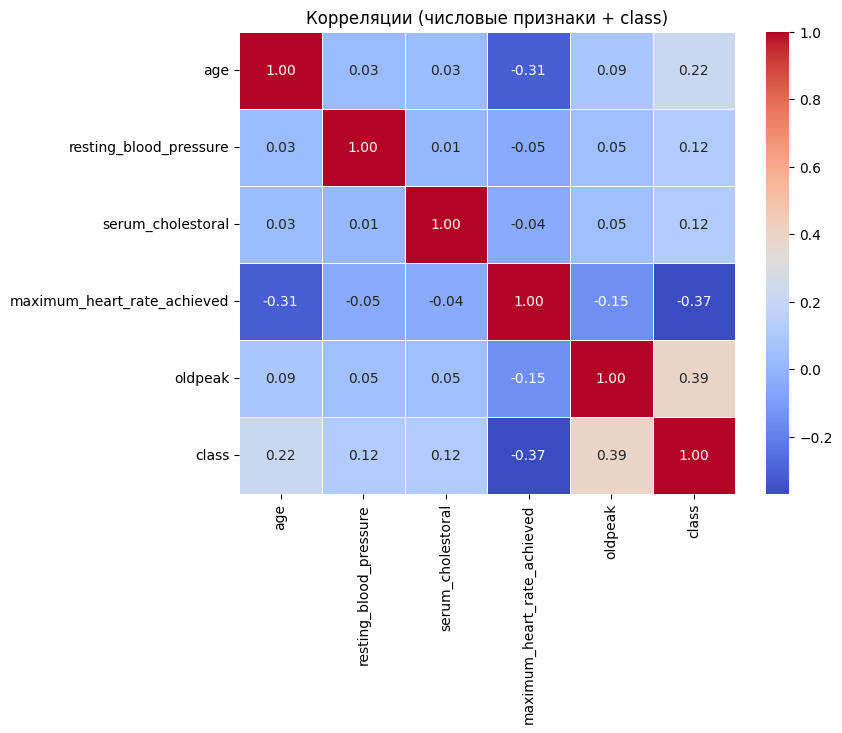

Топ числовых признаков по |corr| с class:
oldpeak                        0.392788
maximum_heart_rate_achieved    0.368760
age                            0.222008
serum_cholestoral              0.117765
resting_blood_pressure         0.115044
Name: class, dtype: float64


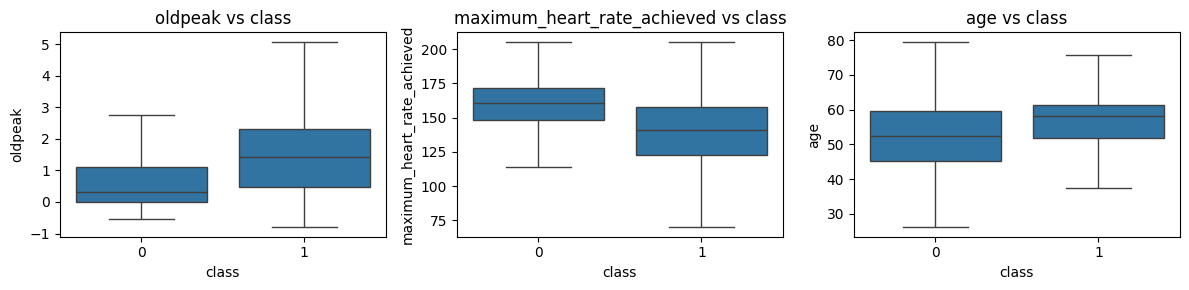

In [11]:
# Корреляционная матрица (по числовым признакам)
num_features = [
    "age",
    "resting_blood_pressure",
    "serum_cholestoral",
    "maximum_heart_rate_achieved",
    "oldpeak",
]

corr_df = train[num_features + ["class"]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Корреляции (числовые признаки + class)")
plt.show()

# Топ признаков по абсолютной корреляции с class
corr_with_target = corr_df["class"].drop("class").abs().sort_values(ascending=False)
print("Топ числовых признаков по |corr| с class:")
print(corr_with_target)

# Более корректная визуализация для бинарной цели: boxplot признака по классам
top_k = corr_with_target.index[:3]
plt.figure(figsize=(12, 3))
for i, col in enumerate(top_k, start=1):
    plt.subplot(1, 3, i)
    sns.boxplot(x="class", y=col, data=train, showfliers=False)
    plt.title(f"{col} vs class")
plt.tight_layout()
plt.show()


### Вывод (пункт 3.2)
Самые информативные числовые признаки для цели — oldpeak (+0.39) и maximum_heart_rate_achieved (-0.37), затем age (+0.22) . Эти признаки стоит считать приоритетными при интерпретации модели. serum_cholestoral и resting_blood_pressure (~0.11–0.12) дают слабый линейный сигнал по отдельности. Мультиколлинеарности между признаками нет


## 3.3 Оценка выбросов (boxplot на исходных шкалах)

Boxplot’ы ниже строятся **до масштабирования**: так “выбросы” видны в исходных единицах и не путаются с отрицательными значениями, которые могли бы появиться просто из-за `StandardScaler`.


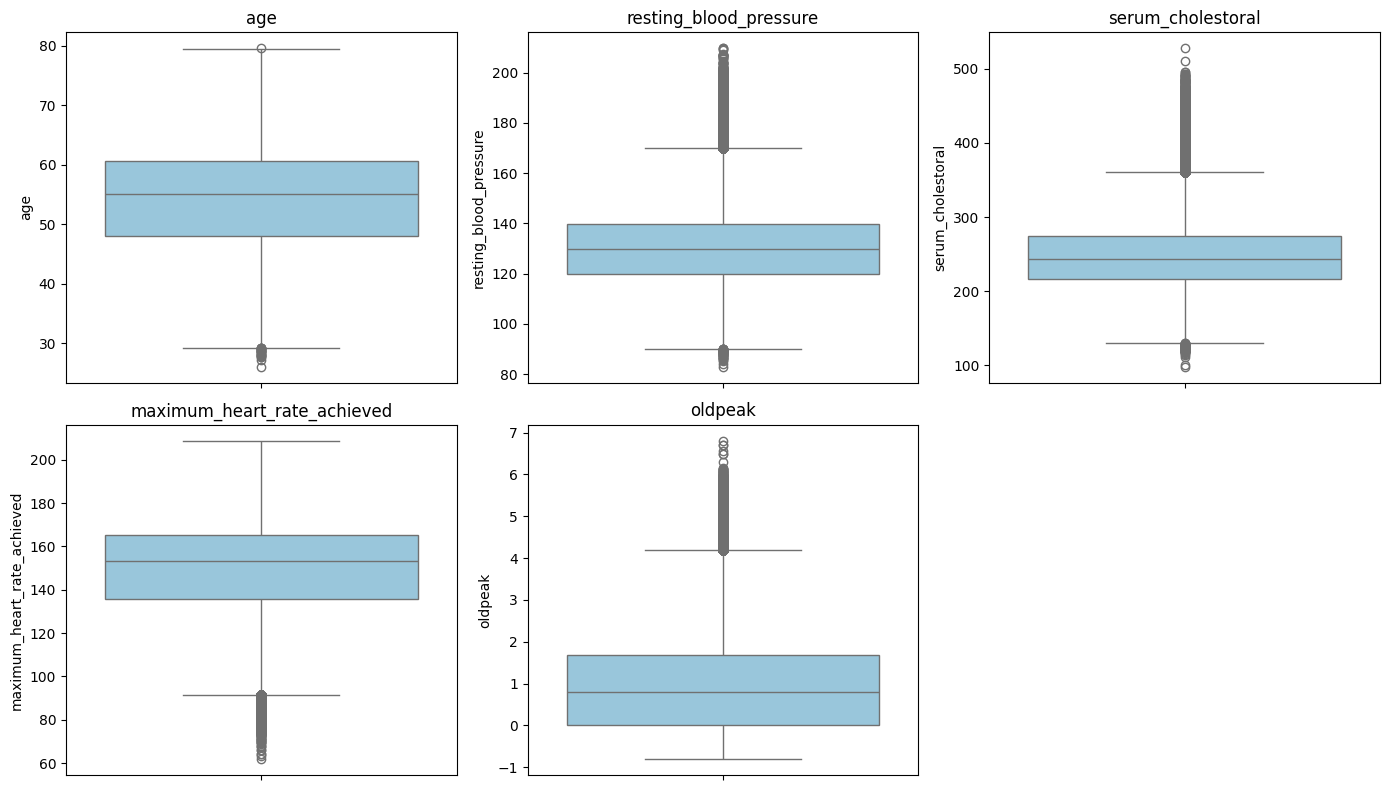

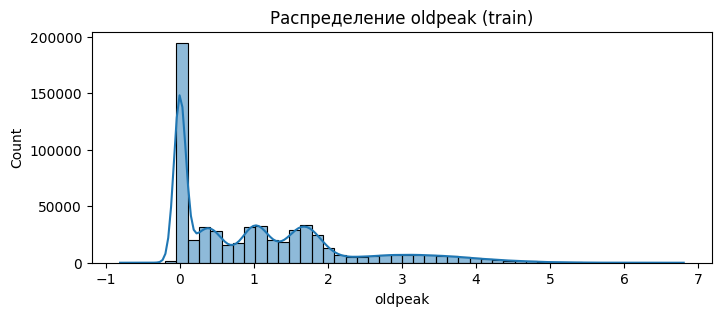

In [12]:
# Boxplot для числовых признаков (сырые значения)

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_features, start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=train[col], color="#8ecae6")
    plt.title(col)
plt.tight_layout()
plt.show()

# Дополнительно: распределения oldpeak (есть отрицательные значения)
plt.figure(figsize=(8, 3))
sns.histplot(train["oldpeak"], bins=50, kde=True)
plt.title("Распределение oldpeak (train)")
plt.show()


### Вывод (пункт 3.3)
Выбросы есть почти во всех числовых признаках. age выглядит наиболее “спокойным”: распределение компактнее, выбросов меньше.oldpeak имеет сильную асимметрию вправо

## 3.4 Фильтрация и исправление невалидных значений

In [13]:
# Критерий: "фильтрация невалидных значений".
# Стратегия: значения вне ожидаемых диапазонов переводим в NaN, дальше они будут обработаны импутером в пайплайне.

train_clean = train.copy()
test_clean = test.copy()

# Ожидаемые диапазоны
valid_ranges = {
    "sex": (0, 1),
    "fasting_blood_sugar": (0, 1),
    "resting_electrocardiographic_results": (0, 2),
    "exercise_induced_angina": (0, 1),
    "slope": (1, 3),
    "number_of_major_vessels": (0, 3),
    "thal": (3, 7),
    # chest по заданию 1..4, но в данных он float; оставляем как числовой и тоже ограничим диапазоном
    "chest": (1, 4),
}

# Какие признаки ожидаем как целочисленные категории
int_like = {
    "sex",
    "fasting_blood_sugar",
    "resting_electrocardiographic_results",
    "exercise_induced_angina",
    "slope",
    "number_of_major_vessels",
    "thal",
}


def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col, (lo, hi) in valid_ranges.items():
        if col not in df.columns:
            continue

        # для категориальных int-like аккуратно округляем
        if col in int_like:
            df[col] = np.rint(df[col]).astype("float64")

        # значения вне диапазона -> NaN
        mask_bad = (df[col] < lo) | (df[col] > hi)
        df.loc[mask_bad, col] = np.nan

    return df


train_clean = clean_df(train_clean)
test_clean = clean_df(test_clean)

print("NAs after cleaning (train):")
print(train_clean.isna().sum().sort_values(ascending=False).head(10))


NAs after cleaning (train):
chest                                   10392
age                                         0
ID                                          0
sex                                         0
resting_blood_pressure                      0
serum_cholestoral                           0
fasting_blood_sugar                         0
resting_electrocardiographic_results        0
maximum_heart_rate_achieved                 0
exercise_induced_angina                     0
dtype: int64


### Вывод (пункт 3.4)
- созданы копии train и test (train_clean, test_clean)
- создан словарь с допустимыми границами
- после очистки только в столбце chest 10392 значений NaN

## Вывод (пункт 3)

- Проведён анализ распределений и связей: проверены дубликаты/баланс классов, построены корреляции (heatmap) и оценены выбросы (boxplot).
- Выделены признаки, потенциально связанные с целевой переменной, и сформировано понимание, какие преобразования понадобятся на этапе предобработки.


# 4. Предобработка данных

Дальше — подготовка признаков для моделей (кодирование категориальных, масштабирование числовых, разбиение на train/valid) через пайплайны, чтобы не было рассинхронизации train/test и утечки данных.


In [14]:
# 4.1 Подготовка признаков и разбиение на train/val

TARGET_COL = "class"
DROP_COLS = ["ID"]

# Категориальные признаки
# Важно: `chest` в данных выглядит как float с большим числом уникальных значений,
# поэтому One-Hot для него раздувает матрицу признаков. Оставляем `chest` как числовой.
CAT_FEATURES = [
    "sex",
    "fasting_blood_sugar",
    "resting_electrocardiographic_results",
    "exercise_induced_angina",
    "slope",
    "number_of_major_vessels",
    "thal",
]

# Числовые признаки
NUM_FEATURES = [
    "age",
    "resting_blood_pressure",
    "serum_cholestoral",
    "maximum_heart_rate_achieved",
    "oldpeak",
    "chest",
]

# Используем очищенные данные
X = train_clean.drop(columns=[TARGET_COL] + DROP_COLS)
y = train_clean[TARGET_COL]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)

# 4.2 Трансформеры
cat_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        # Делаем OHE разреженным, чтобы не раздувать память.
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

num_pipe_scaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

num_pipe_noscale = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

# Для Logistic Regression и Neural Network (со scaler)
preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", num_pipe_scaled, NUM_FEATURES),
        ("cat", cat_pipe, CAT_FEATURES),
    ],
    remainder="drop",
)

# Для RandomForest (без scaler)
preprocess_noscale = ColumnTransformer(
    transformers=[
        ("num", num_pipe_noscale, NUM_FEATURES),
        ("cat", cat_pipe, CAT_FEATURES),
    ],
    remainder="drop",
)

# 4.3 Подготовленные матрицы
# Для sklearn-моделей удобно оставлять разреженную матрицу (экономит память).
X_train_prepared = preprocess_scaled.fit_transform(X_train)
X_val_prepared = preprocess_scaled.transform(X_val)

print("\nAfter preprocess_scaled:")
print("X_train_prepared shape:", X_train_prepared.shape)
print("X_val_prepared shape:", X_val_prepared.shape)
print("Matrix type:", type(X_train_prepared))

# Список итоговых фич (удобно для интерпретации и отладки)
feature_names = preprocess_scaled.get_feature_names_out()
print("\nTotal features after OHE:", len(feature_names))

# Для нейросети часто нужен dense-массив.
# Важно: переводить 600k строк в dense может быть тяжело по памяти.
# Поэтому ниже — безопасный вариант: готовим dense только для val и небольшого сэмпла train.
X_val_dense = X_val_prepared.toarray() if hasattr(X_val_prepared, "toarray") else X_val_prepared

sample_n = 50000  # можно увеличить/уменьшить при необходимости
X_train_dense = (
    X_train_prepared[:sample_n].toarray()
    if hasattr(X_train_prepared, "toarray")
    else X_train_prepared[:sample_n]
)
y_train_dense = y_train.iloc[:sample_n]

print("\nDense matrices for NN:")
print("X_train_dense:", X_train_dense.shape, "y_train_dense:", y_train_dense.shape)
print("X_val_dense:", X_val_dense.shape, "y_val:", y_val.shape)


Shapes:
X_train: (480000, 13) y_train: (480000,)
X_val: (120000, 13) y_val: (120000,)

After preprocess_scaled:
X_train_prepared shape: (480000, 25)
X_val_prepared shape: (120000, 25)
Matrix type: <class 'numpy.ndarray'>

Total features after OHE: 25

Dense matrices for NN:
X_train_dense: (50000, 25) y_train_dense: (50000,)
X_val_dense: (120000, 25) y_val: (120000,)


## Готовые пайплайны для моделей

Ниже — заготовки пайплайнов (предобработка + модель) для Logistic Regression и RandomForest. Для нейросети можно использовать `X_train_prepared` / `X_val_prepared` из предыдущей ячейки.


In [15]:
pipe_lr = Pipeline(
    steps=[
        ("prep", preprocess_scaled),
        ("model", LogisticRegression(max_iter=2000, n_jobs=-1)),
    ]
)

pipe_rf = Pipeline(
    steps=[
        ("prep", preprocess_noscale),
        ("model", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
    ]
)

print("Pipelines created:", pipe_lr is not None, pipe_rf is not None)


Pipelines created: True True


## Вывод (пункт 4)

- Проведена очистка/фильтрация невалидных значений и сформированы `train_clean`/`test_clean` для дальнейшей работы.
- Собрана воспроизводимая схема предобработки через `ColumnTransformer`/`Pipeline` (кодирование категорий + масштабирование числовых для моделей, которым это нужно).


# 5. Обучение моделей

Ниже обучаем и сравниваем 3 модели: **Logistic Regression**, **Random Forest**, **Neural Network (PyTorch)**. Оценка проводится на валидационной выборке `X_val / y_val`.


In [16]:
# Общие функции для оценки моделей

def evaluate_sklearn_model(model, X_tr, y_tr, X_te, y_te, title: str):
    model.fit(X_tr, y_tr)

    # Вероятности нужны для ROC-AUC
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    auc = roc_auc_score(y_te, y_proba)
    print(f"{title} | ROC-AUC: {auc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_te, y_pred, digits=4))

    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, values_format="d")
    plt.title(f"Confusion matrix: {title}")
    plt.show()

    RocCurveDisplay.from_predictions(y_te, y_proba)
    plt.title(f"ROC curve: {title}")
    plt.show()

    return auc


## 5.1 Logistic Regression

Логистическая регрессия чувствительна к масштабу признаков, поэтому используем `pipe_lr` (в нём `StandardScaler` для числовых и One-Hot для категориальных).


c:\Users\MSI\Desktop\Глубокое обучение и нейронные сети. Итоговый проект (PJ)\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression | ROC-AUC: 0.9529

Classification report:
              precision    recall  f1-score   support

           0     0.8896    0.9045    0.8970     66698
           1     0.8780    0.8596    0.8687     53302

    accuracy                         0.8845    120000
   macro avg     0.8838    0.8820    0.8828    120000
weighted avg     0.8844    0.8845    0.8844    120000



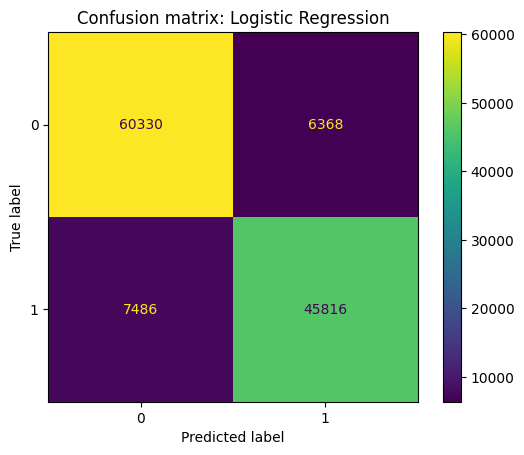

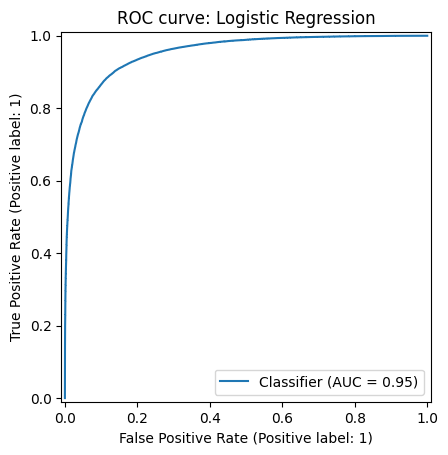

In [17]:
auc_lr = evaluate_sklearn_model(
    pipe_lr,
    X_train,
    y_train,
    X_val,
    y_val,
    title="Logistic Regression",
)


## 5.2 Random Forest

Случайный лес не требует масштабирования, поэтому используем `pipe_rf` (OHE для категориальных + без `StandardScaler`).


Random Forest | ROC-AUC: 0.9598

Classification report:
              precision    recall  f1-score   support

           0     0.9031    0.9134    0.9083     66698
           1     0.8901    0.8774    0.8837     53302

    accuracy                         0.8974    120000
   macro avg     0.8966    0.8954    0.8960    120000
weighted avg     0.8974    0.8974    0.8974    120000



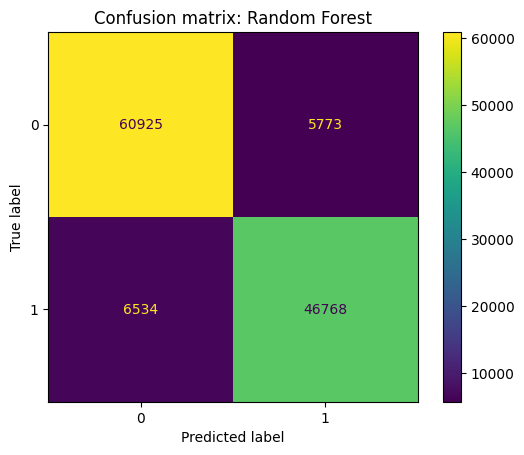

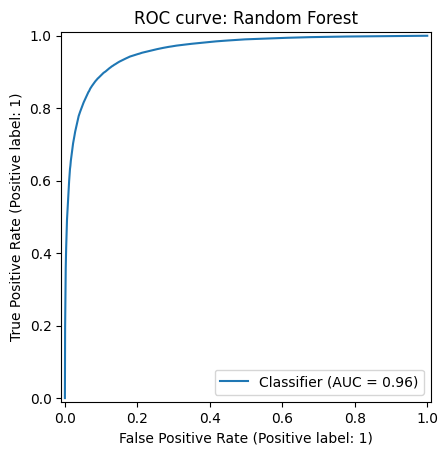

In [18]:
auc_rf = evaluate_sklearn_model(
    pipe_rf,
    X_train,
    y_train,
    X_val,
    y_val,
    title="Random Forest",
)


## 5.3 Neural Network (PyTorch)

Ниже — простая полносвязная сеть (MLP) на PyTorch. Она обучается на подготовленных матрицах `X_train_dense / y_train_dense` и проверяется на `X_val_dense / y_val`.


In [19]:
# PyTorch
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
set_seed(42)


Device: cpu


In [20]:
# Даталоадеры

Xtr = torch.tensor(X_train_dense, dtype=torch.float32)
ytr = torch.tensor(y_train_dense.values, dtype=torch.float32).view(-1, 1)

Xva = torch.tensor(X_val_dense, dtype=torch.float32)
yva = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=1024, shuffle=True)
val_loader = DataLoader(TensorDataset(Xva, yva), batch_size=4096, shuffle=False)

input_dim = Xtr.shape[1]
print("Input dim:", input_dim)


Input dim: 25


In [21]:
# Модель (MLP)

class MLP(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


model = MLP(input_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)


MLP(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


Epoch 01/10 | train_loss=0.4620 | val_auc=0.9497
Epoch 02/10 | train_loss=0.2836 | val_auc=0.9550
Epoch 03/10 | train_loss=0.2753 | val_auc=0.9566
Epoch 04/10 | train_loss=0.2709 | val_auc=0.9576
Epoch 05/10 | train_loss=0.2669 | val_auc=0.9581
Epoch 06/10 | train_loss=0.2645 | val_auc=0.9585
Epoch 07/10 | train_loss=0.2636 | val_auc=0.9589
Epoch 08/10 | train_loss=0.2616 | val_auc=0.9589
Epoch 09/10 | train_loss=0.2615 | val_auc=0.9591
Epoch 10/10 | train_loss=0.2604 | val_auc=0.9592


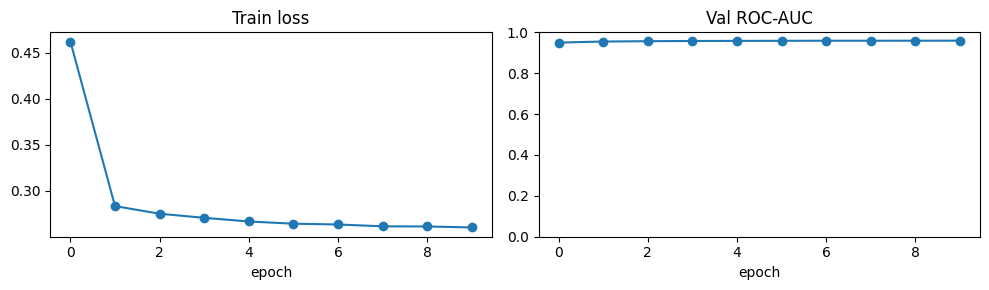


Neural Network (PyTorch) | ROC-AUC: 0.9591644499690302

Classification report:
              precision    recall  f1-score   support

           0     0.8930    0.9200    0.9063     66698
           1     0.8959    0.8621    0.8787     53302

    accuracy                         0.8942    120000
   macro avg     0.8945    0.8910    0.8925    120000
weighted avg     0.8943    0.8942    0.8940    120000



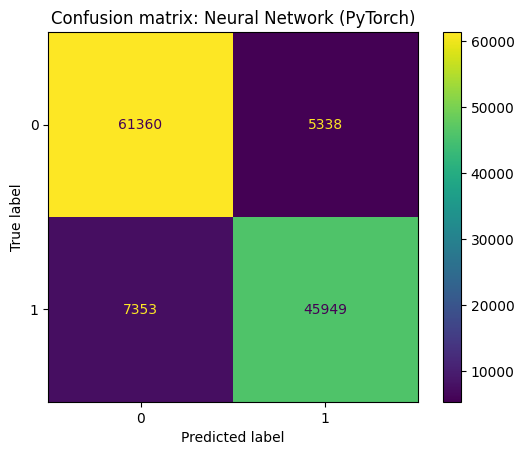

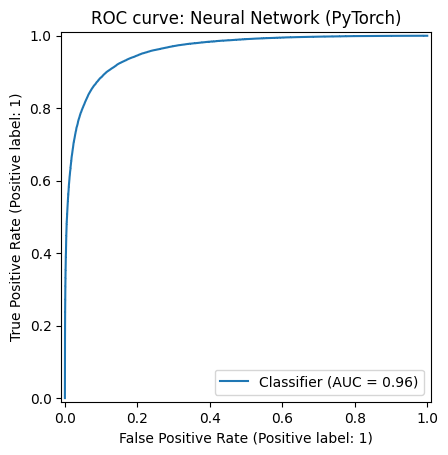

In [22]:
# Обучение + метрики

def predict_proba_torch(model, loader):
    model.eval()
    probs = []
    ys = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            p = torch.sigmoid(logits).cpu().numpy().ravel()
            probs.append(p)
            ys.append(yb.numpy().ravel())
    return np.concatenate(probs), np.concatenate(ys)


epochs = 10
history = {"train_loss": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    model.train()
    running = 0.0
    n = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running += loss.item() * xb.size(0)
        n += xb.size(0)

    train_loss = running / n

    val_proba, val_y = predict_proba_torch(model, val_loader)
    val_auc = roc_auc_score(val_y, val_proba)

    history["train_loss"].append(train_loss)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} | val_auc={val_auc:.4f}")

# Графики обучения
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], marker="o")
plt.title("Train loss")
plt.xlabel("epoch")

plt.subplot(1, 2, 2)
plt.plot(history["val_auc"], marker="o")
plt.title("Val ROC-AUC")
plt.xlabel("epoch")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

# Итоговая оценка
val_pred = (val_proba >= 0.5).astype(int)
auc_nn = roc_auc_score(val_y, val_proba)

print("\nNeural Network (PyTorch) | ROC-AUC:", auc_nn)
print("\nClassification report:")
print(classification_report(val_y.astype(int), val_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(val_y.astype(int), val_pred, values_format="d")
plt.title("Confusion matrix: Neural Network (PyTorch)")
plt.show()

RocCurveDisplay.from_predictions(val_y, val_proba)
plt.title("ROC curve: Neural Network (PyTorch)")
plt.show()


## Вывод (пункт 5)

- Обучены 3 модели (LogReg, RandomForest, MLP на PyTorch) и получены метрики качества на валидации (в т.ч. `ROC-AUC`).
- Построены графики/кривые и матрицы ошибок, что позволяет сравнить модели не только по числу, но и по типам ошибок.


# 6. Сравнение моделей

Сравним модели по метрике **ROC-AUC** на валидационной выборке.


,model,roc_auc
1,Random Forest,0.959838
2,Neural Network (PyTorch),0.959164
0,Logistic Regression,0.952893


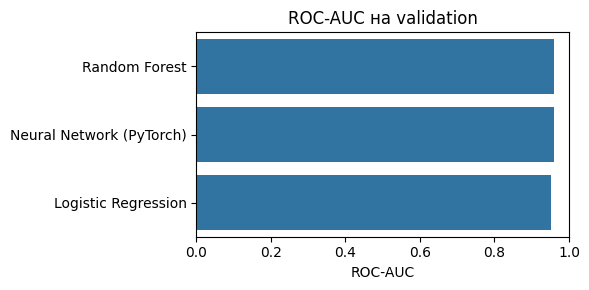

In [23]:
results = pd.DataFrame(
    {
        "model": [
            "Logistic Regression",
            "Random Forest",
            "Neural Network (PyTorch)",
        ],
        "roc_auc": [auc_lr, auc_rf, auc_nn],
    }
).sort_values("roc_auc", ascending=False)

display(results)

plt.figure(figsize=(6, 3))
sns.barplot(data=results, x="roc_auc", y="model", orient="h")
plt.xlim(0.0, 1.0)
plt.title("ROC-AUC на validation")
plt.xlabel("ROC-AUC")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Вывод по сравнению моделей

- Сравнение на валидационной выборке показало, что **наибольшее значение ROC-AUC** имеет модель, которая находится **на 1‑й строке таблицы `results`** (после сортировки по `roc_auc`).
- Разница в ROC-AUC между моделями показывает, насколько лучше/хуже модель **разделяет классы** (чем выше ROC-AUC, тем лучше качество ранжирования).
- Для дальнейшего этапа (**инференс на `test.csv`**) логично выбрать **лучшую по ROC-AUC модель** из таблицы `results` и дообучить её на всём `train`.

Дополнительно:
- Если ROC-AUC у моделей близкий, можно выбирать модель, которая проще в эксплуатации (скорость/интерпретируемость): например, Logistic Regression часто проще и быстрее, Random Forest может быть тяжелее, нейросеть требует больше настроек.


## Вывод (пункт 6)

- Сведены результаты моделей в единую таблицу и визуально сравнен `ROC-AUC`.
- По валидации выбрана модель‑лидер; именно её логика далее используется для финального обучения и инференса.


# 7. Инференс на `test.csv` и подготовка `submission.csv`

Ниже выбираем лучшую модель по `roc_auc` (из таблицы `results`), дообучаем её на всём `train`, делаем предсказания на `test.csv` и сохраняем файл `submission.csv` в формате, как в `sample_submission.csv`.


In [24]:
# Выбор лучшей sklearn-модели по таблице results
# (PyTorch модель здесь не используем для submission, т.к. нужен отдельный препроцессинг/инференс.)

best_row = results.iloc[0]
best_model_name = best_row["model"]
print("Best model by ROC-AUC:", best_model_name)

if best_model_name == "Logistic Regression":
    best_pipe = pipe_lr
elif best_model_name == "Random Forest":
    best_pipe = pipe_rf
else:
    # если вдруг наверху окажется нейросеть, берём лучшую sklearn-модель
    print("Top model is PyTorch NN. For submission we use best sklearn model instead.")
    best_pipe = pipe_lr if auc_lr >= auc_rf else pipe_rf
    print("Chosen sklearn model:", "Logistic Regression" if best_pipe is pipe_lr else "Random Forest")

# Обучаем на всём train (очищенные данные)
X_full = train_clean.drop(columns=[TARGET_COL] + DROP_COLS)
y_full = train_clean[TARGET_COL]

best_pipe.fit(X_full, y_full)
print("Trained best_pipe on full train.")


Best model by ROC-AUC: Random Forest
Trained best_pipe on full train.


In [25]:
# Предсказание на test и сохранение submission.csv

X_test = test_clean.drop(columns=DROP_COLS)

# Вероятность класса 1
test_proba = best_pipe.predict_proba(X_test)[:, 1]

# Вариант как в sample_submission.csv: 0/1 по порогу 0.5
test_pred = (test_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    "ID": test_clean["ID"].values,
    "class": test_pred,
})

submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)

print("Saved:", submission_path)
display(submission.head())


Saved: submission.csv


,ID,class
0,600000,1
1,600001,1
2,600002,0
3,600003,0
4,600004,0


## Вывод (пункт 7)

- Выполнен инференс на `test.csv`: выбрана лучшая модель по `roc_auc`, дообучена на всём `train` и сформирован `submission.csv` в формате `ID,class`.
- Дополнительно сохранены артефакты модели (пайплайн/веса), чтобы инференс можно было повторить без переобучения.


In [26]:
# 7.1 Сохранение лучшей модели (sklearn) и весов PyTorch

# сохраняем выбранную sklearn-модель (вместе с препроцессингом внутри pipeline)
joblib.dump(best_pipe, "best_model.joblib")
print("Saved sklearn model to best_model.joblib")

# сохраняем веса PyTorch-модели (если она обучалась)
try:
    torch.save(model.state_dict(), "pytorch_model.pt")
    print("Saved PyTorch weights to pytorch_model.pt")
except Exception as e:
    print("PyTorch weights were not saved:", e)


Saved sklearn model to best_model.joblib
Saved PyTorch weights to pytorch_model.pt
